# SEBAL Notebook 8 — Compare First-Pass vs Refined ET
**Scene:** Landsat 7 (2020-01-19)  
**Region:** Mississippi Delta (EPSG:32615)

This notebook compares first-pass and refined SEBAL evapotranspiration outputs and summarizes the differences.

## 1. Import libraries

In [1]:
import os
import numpy as np
from Utility import read_raster

## 2. Load rasters

In [2]:
indices_dir = r"G:\Collaborations\Mentee\UF_Anitha Madapakula\Scripts\Python\SEBAL_20200119_MSDelta\04_indices"
date = "20200119"
hour_tag = "16Z"
region = "MSDelta"

ET24_firstpass_path = os.path.join(indices_dir, f"ET24_firstpass_{date}_{hour_tag}_{region}.tif")
ET24_refined_path   = os.path.join(indices_dir, f"ET24_refined_{date}_{hour_tag}_{region}.tif")

ET24_firstpass, profile, _ = read_raster(ET24_firstpass_path)
ET24_refined, _, _          = read_raster(ET24_refined_path)

## 2. Compute difference

In [3]:
ET_diff = np.full(ET24_refined.shape, -9999.0, dtype="float32")

valid = (ET24_firstpass > -9999) & (ET24_refined > -9999)

ET_diff[valid] = ET24_refined[valid] - ET24_firstpass[valid]

print("ET_diff min/max:",
      float(ET_diff[ET_diff > -9999].min()),
      float(ET_diff[ET_diff > -9999].max()))

ET_diff min/max: -4.887548923492432 -7.174745064730814e-07


In [4]:
valid_vals = ET_diff[ET_diff > -9999]

print("Mean:", float(valid_vals.mean()))
print("Std:", float(valid_vals.std()))

Mean: -2.0517172813415527
Std: 0.7575321793556213


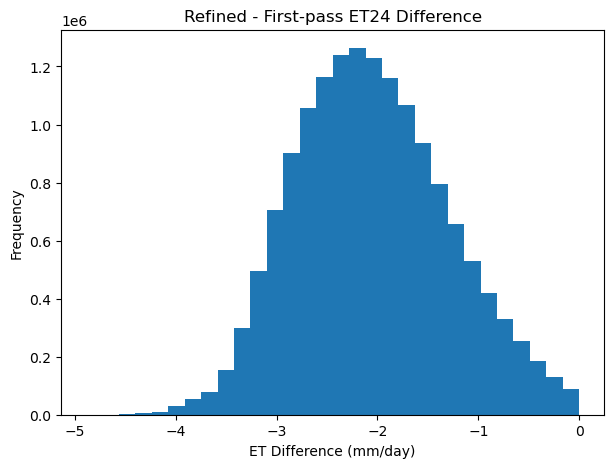

In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))
plt.hist(valid_vals, bins=30)
plt.title("Refined - First-pass ET24 Difference")
plt.xlabel("ET Difference (mm/day)")
plt.ylabel("Frequency")
plt.show()